In [2]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
from matplotlib import gridspec 
%matplotlib inline 

import seaborn as sns 

from warnings import filterwarnings 
filterwarnings('ignore')

from math import factorial 

from scipy import stats 
from scipy.stats import randint 
from scipy.stats import skewnorm

import random

In [3]:
plt.rcParams['figure.figsize'] = [16,10]

In [4]:
import os 
os.getcwd()

'C:\\Users\\monke'

In [5]:
# Always display all columns
pd.set_option('display.max_columns', None)


In [6]:
hdf = pd.read_csv('/Users/monke/PythonEDAProjects/hotelBookingsEDAProject/hotel_booking_latest.csv')
hdf.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [7]:
hdf.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'name', 'email',
       'phone-number', 'credit_card'],
      dtype='object')

In [8]:
df = (hdf.copy()).convert_dtypes()  
print('"is_canceled" and "is_repeated_guest" look like booleans and have 2 values, 1 and 0. Hence converting it to boolean for effective analysis')
df[['is_canceled', 'is_repeated_guest']] = df[['is_canceled', 'is_repeated_guest']].astype(bool)


"is_canceled" and "is_repeated_guest" look like booleans and have 2 values, 1 and 0. Hence converting it to boolean for effective analysis


In [9]:
def cleaningData(df):
    df2 = df.copy()
    print('Filling 0 for nulls in the 2 columns...')
    df2['company'] = df2['company'].fillna(0)
    df2['agent'] = df2['agent'].fillna(0)
    print('Filling "Unknown" for a country that\'s not listed:...')
    df2['country'] = df2['country'].fillna('Unknown')
    print('If the "children" columns has null, probably means they don\'t have children')
    df2['children'] = df2['children'].fillna(0)
    return df2 

In [10]:
df = cleaningData(df)
print('Cleaned data:')
display(df.info())

Filling 0 for nulls in the 2 columns...
Filling "Unknown" for a country that's not listed:...
If the "children" columns has null, probably means they don't have children
Cleaned data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  string 
 1   is_canceled                     119390 non-null  bool   
 2   lead_time                       119390 non-null  Int64  
 3   arrival_date_year               119390 non-null  Int64  
 4   arrival_date_month              119390 non-null  string 
 5   arrival_date_week_number        119390 non-null  Int64  
 6   arrival_date_day_of_month       119390 non-null  Int64  
 7   stays_in_weekend_nights         119390 non-null  Int64  
 8   stays_in_week_nights            119390 non-null  Int64  
 9   adults            

None

## Sampling
Learning about Sampling. Here's a short explanation for the same.
Is is the method of selecting a subset of observations from the population which is used as a represntative of the population

The Value associated with the charactiristic of the population is known as a 'parameter' and the characteristic of the sample is described by a 'statistic'. The sample from a population is used to estimate the values of parameter. 

Different types of sampling:
1. Simple Random
2. Stratified
3. Systematic
4. Cluster Sampling

### 1.1 Simple Random Sample
It is one of the sampling methods in which each obsercation in the population has an equal chance (probability) of being selected as the sample. It is the most basic type of sampling. 

Simple random sampling can be done with/without replacement. In Simple Random Sampling With Replacement(SRSWR) an observation can occur multiple times, as we replace the selected observation in the population before drawing the next sample. In this technique, the size of the population remains the same. 
If there are 'N' observations in the population then the proability of drawing n samples with replacement is 1/N**n

#### Example:
1. Consider 8 identical boxes that contain different number of shuttlecocks. Draw a sample of 20 boxes with replacement.
data = [18, 13, 16, 17, 15, 21, 19, 12]

In [11]:
data = [18, 13, 16, 17, 15, 21, 19, 12] 
# pass the data to the parameter, 'population'
# pass the required sample size to the paramter, k 
sample_wr = random.choices(population= data, k=20)

print(sample_wr)

[13, 15, 12, 19, 18, 17, 19, 17, 21, 19, 18, 13, 16, 13, 17, 19, 12, 17, 16, 12]


Used Sampling technique to randomly select rows with the sample credit cards

In [12]:
cc = hdf['credit_card']
sample_credit_cards = random.choices(population=cc, k=40)
print(sample_credit_cards)
print(len(sample_credit_cards))
hdf[hdf['credit_card'].isin(sample_credit_cards)]

['************8312', '************7900', '************4694', '************2900', '************6643', '************4320', '************2248', '************5820', '************6973', '************1606', '************3407', '************8974', '************2572', '************7513', '************1149', '************9114', '************2521', '************3914', '************2588', '************2999', '************7704', '************3629', '************3440', '************9666', '************5580', '************8824', '************1289', '************2046', '************5837', '************2162', '************8068', '************7374', '************8643', '************7342', '************5186', '************8937', '************2769', '************3525', '************5015', '************7238']
40


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
66,Resort Hotel,0,3,2015,July,27,3,0,2,2,0.0,0,BB,ESP,Online TA,TA/TO,0,0,0,A,C,0,No Deposit,240.0,NaN,0,Transient,110.50,0,0,Check-Out,2015-07-05,Melinda Flores,Flores_Melinda@yahoo.com,419-443-6780,************9114
99,Resort Hotel,0,102,2015,July,27,3,2,5,2,0.0,0,BB,DEU,Direct,Direct,0,0,0,E,E,0,No Deposit,250.0,NaN,0,Transient,90.95,0,0,Check-Out,2015-07-10,Susan Wilson,Wilson_Susan@comcast.net,253-535-6431,************9666
239,Resort Hotel,0,16,2015,July,28,9,1,3,1,0.0,0,BB,RUS,Direct,Direct,0,0,0,A,A,0,No Deposit,250.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-13,Kristen Williams,Kristen.Williams@protonmail.com,421-586-4415,************2999
383,Resort Hotel,0,56,2015,July,29,13,1,3,2,0.0,0,HB,ESP,Online TA,TA/TO,0,0,0,A,A,1,No Deposit,240.0,NaN,0,Transient,134.25,1,0,Check-Out,2015-07-17,Monica Gibbs,Monica.G@att.com,662-170-0797,************7513
775,Resort Hotel,1,119,2015,July,31,29,0,4,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,108.54,0,1,Canceled,2015-04-04,Sean Hall,Sean.Hall@gmail.com,304-456-0081,************6643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118126,City Hotel,0,504,2017,August,32,12,2,1,2,0.0,0,BB,GBR,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,229.0,NaN,0,Transient-Party,112.67,0,1,Check-Out,2017-08-15,Debra Jordan,DJordan86@mail.com,137-366-0511,************6973
118724,City Hotel,0,2,2017,August,34,24,0,1,2,0.0,0,BB,MEX,Groups,TA/TO,0,0,0,A,A,0,No Deposit,147.0,NaN,0,Transient-Party,140.00,0,1,Check-Out,2017-08-25,Anthony Ho,Anthony.H@comcast.net,682-835-5586,************8937
118961,City Hotel,0,457,2017,August,34,25,0,2,2,0.0,0,HB,DEU,Offline TA/TO,TA/TO,0,0,0,A,A,1,No Deposit,6.0,NaN,0,Transient-Party,122.40,0,1,Check-Out,2017-08-27,Joseph Armstrong,Joseph.A76@aol.com,585-629-5660,************7238
119122,City Hotel,0,40,2017,August,35,29,0,1,1,0.0,0,BB,PRT,Corporate,Corporate,0,0,0,D,D,0,No Deposit,NaN,451.0,0,Transient,95.00,0,0,Check-Out,2017-08-30,Valerie Ramirez,Ramirez.Valerie@verizon.com,265-792-0123,************2999


In Simple Random Sample WithOut Replacement(SRSWOR), an observation can occur only once as we do not replace the selected observation before drawing the next sample. 
If there are N observations in the popuulation then the probabity of drawing n samples without replacement is $\frac{1}{N \choose n}$

#### Example
1. An ice-cream manufacturer wants to study the sales of ice-creams to decide the production policies of the company. He collects the data for the number of ice-creams sold in a month from the 30 franchise. Randomly select the sales of 10 franchise for the study.

data = [21, 93, 62, 76, 73, 20, 56, 95, 41, 36, 38, 13, 80, 88, 34, 18, 40, 11, 25, 29, 61, 23, 82, 10, 92, 69, 60, 87, 14, 91]

In [13]:
sample_credit_cards_wo = random.sample(population=sorted(cc), k=40)

print(sample_credit_cards_wo)
print('All the columns:')
hdf[hdf['credit_card'].isin(sample_credit_cards_wo)].head()

['************5298', '************2160', '************1375', '************9518', '************9515', '************9104', '************2364', '************8556', '************7104', '************9057', '************9305', '************6538', '************2073', '************3900', '************1755', '************3705', '************3718', '************4222', '************5876', '************3427', '************5463', '************4746', '************1693', '************2974', '************8351', '************8567', '************9106', '************6365', '************7808', '************1300', '************5325', '************5647', '************2670', '************3130', '************7696', '************4463', '************2449', '************8224', '************3956', '************4009']
All the columns:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
87,Resort Hotel,1,79,2015,July,27,3,6,15,2,1.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,242.0,NaN,0,Transient,108.73,0,2,Canceled,2015-04-15,Jennifer Murphy,Murphy.Jennifer59@yandex.com,704-540-0581,************5298
90,Resort Hotel,0,1,2015,July,27,3,0,1,2,0.0,0,BB,ESP,Online TA,TA/TO,0,0,0,A,C,0,No Deposit,240.0,NaN,0,Transient,131.00,0,1,Check-Out,2015-07-04,Rebecca Hebert,RHebert34@zoho.com,949-133-1514,************5325
252,Resort Hotel,0,11,2015,July,28,10,0,2,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,110.50,0,1,Check-Out,2015-07-12,Brianna Montgomery,Montgomery.Brianna@xfinity.com,720-949-2293,************9305
274,Resort Hotel,0,115,2015,July,28,10,2,7,2,0.0,0,BB,IRL,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,120.60,0,2,Check-Out,2015-07-19,Kyle Singh,Singh_Kyle@hotmail.com,534-089-2176,************9515
514,Resort Hotel,0,44,2015,July,29,18,2,2,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,E,E,1,No Deposit,250.0,NaN,0,Transient,145.00,0,0,Check-Out,2015-07-22,Ryan Hernandez,Ryan.H@aol.com,891-867-4548,************4463


In [14]:
type(cc)

pandas.core.series.Series

## Descriptive Statistics 
Descriptive statistics summarizes or describes the given data. It includes measures of central tendency, measure of dispersion and distribution of data.

### Measure of Central Tendency 
A measure of central tendency is a value that distinguishes the central position of the data. It includes mean, median, mode and partition values of teh data. 

#### Mean: 
It is defined as the ratio of the sum of all the observations to the total number of obsercations. It is affected by the presence of outliers

#### Median; 
It is the middlemost observations in the data when it is arranged in the increasing or decreasing order based on teh values. It divides the dataset into two equal parts. 

#### Mode: 
It is defined as the value in the data with the highest frequenct. There can be more than one mode in the data


#### Partition values:
Partition values are defined as the values that divide the data into equal parts. `Quantiles` divide the data into 4 equal parts, `Deciles` divide the data into 10 equal parts and `Percentiles` divide the data into 100 equal parts. 


In [15]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'name', 'email',
       'phone-number', 'credit_card'],
      dtype='object')

In [16]:
df.describe()

,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0
mean,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103886,0.007949,0.087118,0.137097,0.221124,74.828319,10.775157,2.321149,101.831122,0.062518,0.571363
std,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398555,0.097436,0.844336,1.497437,0.652306,107.141953,53.943884,17.594721,50.53579,0.245291,0.792798
min,0.0,2015.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-6.38,0.0,0.0
25%,18.0,2016.0,16.0,8.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,69.29,0.0,0.0
50%,69.0,2016.0,28.0,16.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,0.0,94.575,0.0,0.0
75%,160.0,2017.0,38.0,23.0,2.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,152.0,0.0,0.0,126.0,0.0,1.0
max,737.0,2017.0,53.0,31.0,19.0,50.0,55.0,10.0,10.0,26.0,72.0,21.0,535.0,543.0,391.0,5400.0,8.0,5.0


In [17]:
print(df.groupby('is_canceled')['adr'].mean())
print(df.groupby('hotel')['adr'].mean())

is_canceled
False     99.987693
True     104.964333
Name: adr, dtype: Float64
hotel
City Hotel      105.304465
Resort Hotel      94.95293
Name: adr, dtype: Float64


Creating Box Plot for various stuff

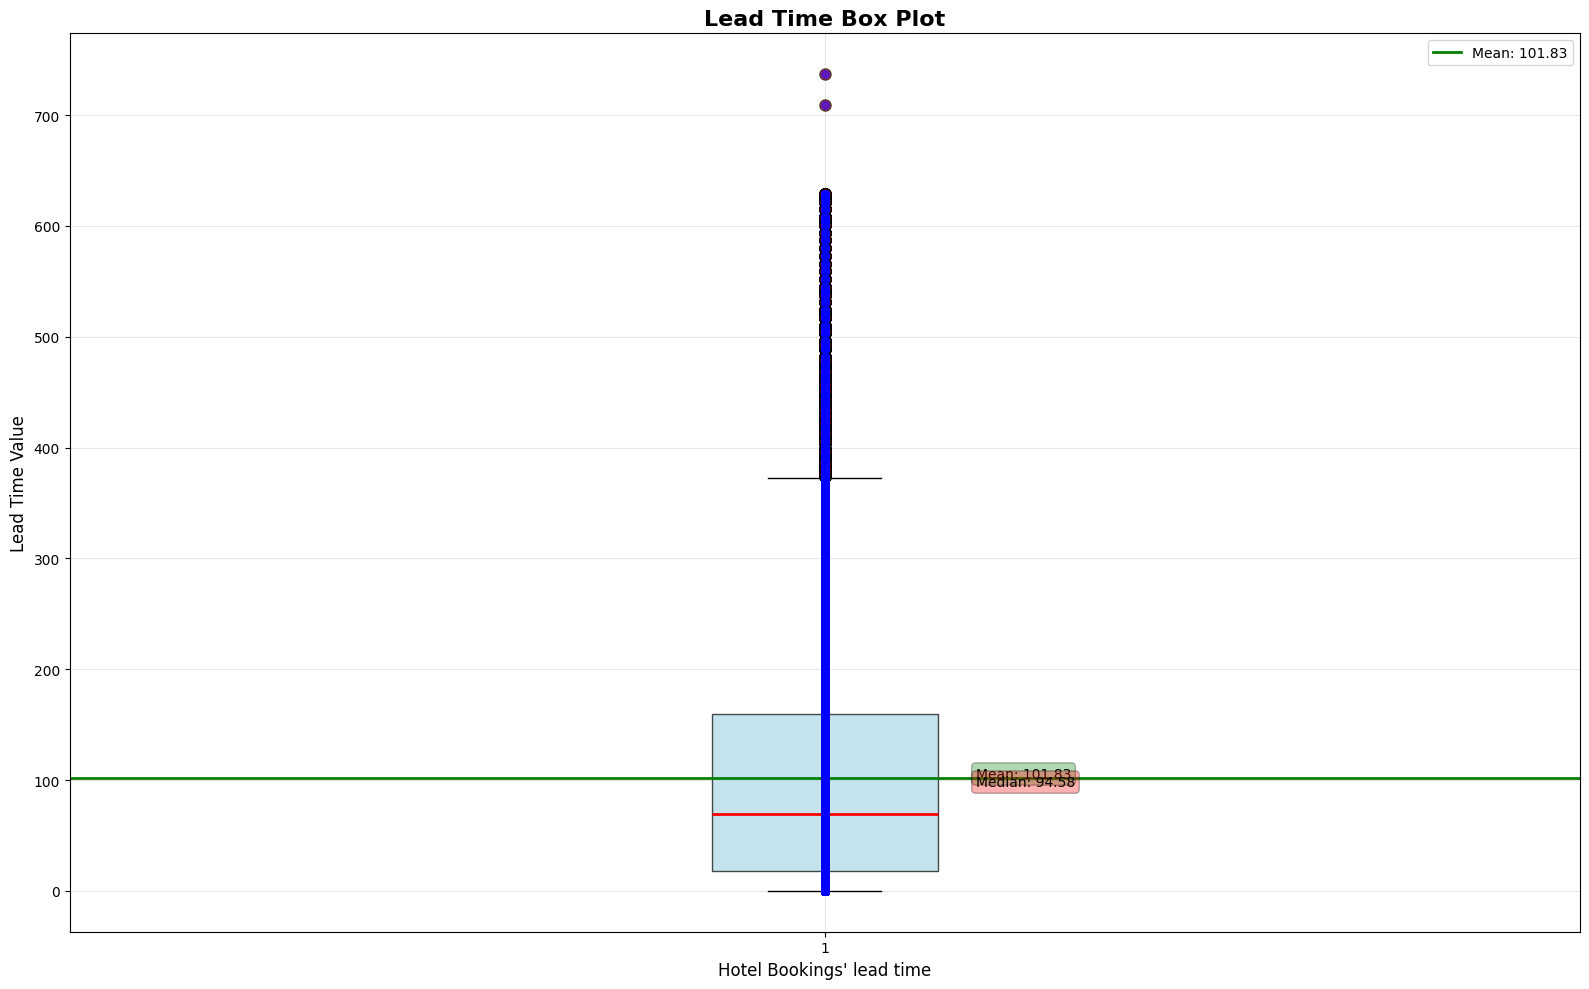

In [18]:
box_plot = plt.boxplot(df['lead_time'], 
                       patch_artist=True,
                       boxprops=dict(facecolor='lightblue', alpha=0.7),
                       medianprops=dict(color='red', linewidth=2), 
                        flierprops=dict(marker='o', markerfacecolor='red', markersize=8, alpha=0.7)
                        )
plt.axhline(y=df['adr'].mean(),
            color='green',
            linestyle='-',
            linewidth=2,
           label=f"Mean: {df['adr'].mean():.2f}")

plt.title('Lead Time Box Plot', fontsize=16, fontweight='bold')
plt.ylabel('Lead Time Value', fontsize=12)
plt.xlabel('Hotel Bookings\' lead time', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend() 

#Adding text annotation to show what where adr stands compared to lead time 
plt.text(1.1, 
         df['adr'].mean(),
        f'Mean: {df['adr'].mean():.2f}',
        fontsize=10,
        bbox=dict(boxstyle="round, pad=0.3", facecolor='green', alpha=0.3)
    )

plt.text(
    1.1, 
    df['adr'].median(), 
    f'Median: {df['adr'].median():.2f}', 
        fontsize=10, 
    bbox=dict(boxstyle="round, pad=0.3", facecolor='red', alpha=0.3)
)

plt.scatter([1]*len(df), df['lead_time'], alpha=0.6, color='blue', s=30, zorder=3)

plt.tight_layout() 
plt.show()


I just realized, the position of Mean and Median of adr seem to be pretty close to the center of lead time. 
I check correlation between these 2. I had chosen both of these on random. Then I was like, How would we compare $ amounts(adr) with lead_time. But it does makes sense. When IS adr really low? What could be the factore contributing to it? Lets just test it out with correlation

In [19]:
df[['lead_time', 'adr']].corr()

,lead_time,adr
lead_time,1.000000,-0.063077
adr,-0.063077,1.000000


Lesser the adr, higher the lead time. So, people have been booking well in advance

In [20]:
#Extra statistics 
print(f"Q1: {np.percentile(df['lead_time'], 25)}")
print(f"Q2: {np.percentile(df['lead_time'], 50)}")
print(f"Median: {df['lead_time'].median()}")
print(f"Q3: {np.percentile(df['lead_time'], 75)}")
print(f"Q4: {np.percentile(df['lead_time'], 100)}")
print(f"Std Deviation: {np.std(df['lead_time'])}")
print(f"Mean: {df['lead_time'].mean()}")

Q1: 18.0
Q2: 69.0
Median: 69.0
Q3: 160.0
Q4: 737.0
Std Deviation: 106.86264950916215
Mean: 104.01141636652986


### Measure of Dispersion
A measure of dispersion describes the variability in the data. Some of the measures of dispersion are range, variancem standard deviation, coefficient of variation and IQR 

#### Range:
It is defined as the difference between the largest and smallest observation in the data. It is affected by the presence of extreme observation. 

#### Variance: (V)
It calculates the dispersion of the data from the mean.It is defined as the average of the sum of squares of the difference between the observation and the mean. 

#### Standard Deviation (SD)
It is the positive square root of variance. The unit of SD is the same as the unit of data poitns. The variable with near-zero SD is least important for data analysis. 

#### Coefficient of Variation 
It is a measure of dispersion of data points around the mean. It is always expressed in percentage. We can compare the coefficient of variation of two or more groups to identify the group with more spread. 

#### Inter Quartile Range (IQR) 
It is defined as the difference between the thors and first quartiles. It returns the range of the middle 50% of the data. IQR can be used to identfy the outliers in the data

In [21]:
df.dtypes

hotel                             string[python]
is_canceled                                 bool
lead_time                                  Int64
arrival_date_year                          Int64
arrival_date_month                string[python]
arrival_date_week_number                   Int64
arrival_date_day_of_month                  Int64
stays_in_weekend_nights                    Int64
stays_in_week_nights                       Int64
adults                                     Int64
children                                   Int64
babies                                     Int64
meal                              string[python]
country                           string[python]
market_segment                    string[python]
distribution_channel              string[python]
is_repeated_guest                           bool
previous_cancellations                     Int64
previous_bookings_not_canceled             Int64
reserved_room_type                string[python]
assigned_room_type  

In [22]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,False,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,False,0,0,C,C,3,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,False,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,False,0,0,C,C,4,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,False,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,False,0,0,A,C,0,No Deposit,0,0,0,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,False,13,2015,July,27,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,False,0,0,A,A,0,No Deposit,304,0,0,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,False,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,False,0,0,A,A,0,No Deposit,240,0,0,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [25]:
bookings_with_babies = df[df['babies']>=1]
bookings_with_babies.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
109,Resort Hotel,False,102,2015,July,27,4,2,5,2,0,1,BB,PRT,Online TA,TA/TO,False,0,0,A,A,0,No Deposit,240,0,0,Transient,73.8,0,2,Check-Out,2015-07-11,Angel Smith,Angel_S@zoho.com,777-065-6700,************8689
111,Resort Hotel,False,78,2015,July,27,4,2,5,2,0,1,HB,PRT,Online TA,TA/TO,False,0,0,E,F,0,No Deposit,240,0,0,Transient,139.0,0,2,Check-Out,2015-07-11,John Rojas,John_R@gmail.com,817-841-9453,************9251
165,Resort Hotel,False,84,2015,July,28,6,1,3,2,0,1,BB,PRT,Online TA,TA/TO,False,0,0,D,E,1,No Deposit,240,0,0,Transient,97.0,0,2,Check-Out,2015-07-10,Natalie Anderson,Anderson_Natalie@gmail.com,109-008-2223,************3320
236,Resort Hotel,False,78,2015,July,28,9,0,3,2,0,1,BB,PRT,Online TA,TA/TO,False,0,0,A,A,0,No Deposit,240,0,0,Transient,82.0,0,2,Check-Out,2015-07-12,Robert Gonzalez,RobertGonzalez@hotmail.com,313-497-8939,************8826
264,Resort Hotel,False,21,2015,July,28,10,2,3,2,0,2,HB,PRT,Direct,Direct,False,0,0,C,C,1,No Deposit,250,0,0,Transient,165.0,1,3,Check-Out,2015-07-15,Patrick Wood,Patrick.W@mail.com,595-110-6891,************3555


In [29]:
bookings_with_babies.groupby('hotel')['lead_time'].mean()

hotel
City Hotel      54.284553
Resort Hotel     93.34854
Name: lead_time, dtype: Float64

In [30]:
bookings_with_babies.groupby('hotel')['lead_time'].var()

hotel
City Hotel      3948.160657
Resort Hotel    8163.825281
Name: lead_time, dtype: Float64

In [31]:
bookings_with_babies.groupby('hotel')['lead_time'].median()

hotel
City Hotel      28.0
Resort Hotel    67.0
Name: lead_time, dtype: Float64

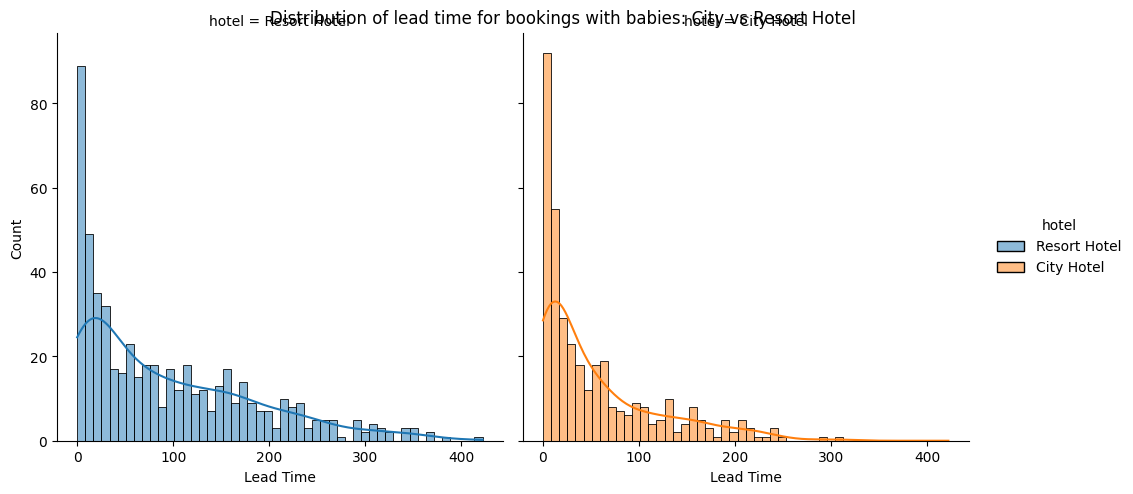

In [33]:
g = sns.displot(
    data=bookings_with_babies, 
    x='lead_time', 
    col= 'hotel', 
    hue='hotel', 
    kind='hist', 
    bins=50, 
    kde=True
)
g.fig.suptitle('Distribution of lead time for bookings with babies: City vs Resort Hotel')
g.set_axis_labels('Lead Time')

plt.show()

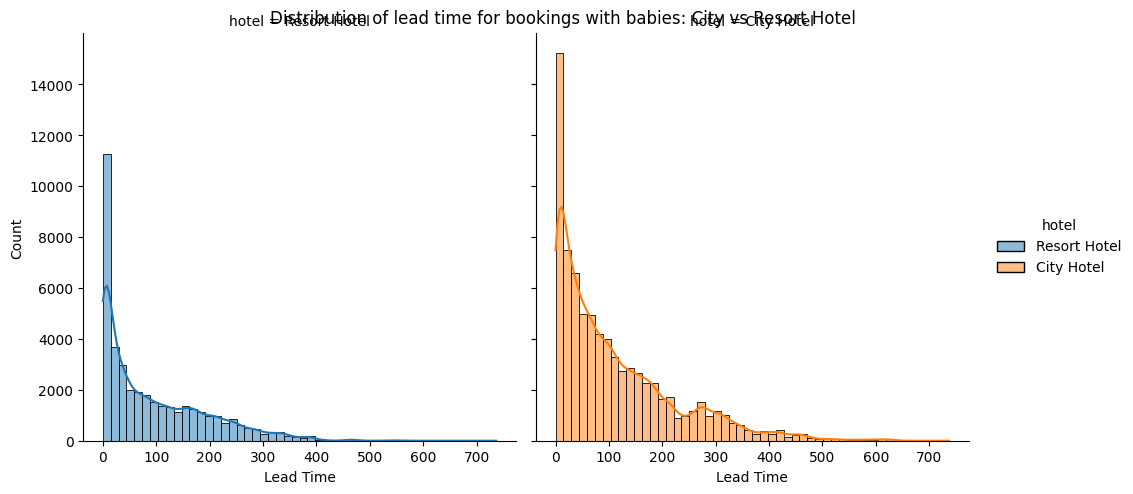

In [41]:
g = sns.displot(
    data=df[df['babies']==0], 
    x='lead_time', 
    col= 'hotel', 
    hue='hotel', 
    kind='hist', 
    bins=50, 
    kde=True
)
g.fig.suptitle('Distribution of lead time for bookings with babies: City vs Resort Hotel')
g.set_axis_labels('Lead Time')

plt.show()

In [35]:
bookings_with_babies.groupby('hotel')['lead_time'].std()

hotel
City Hotel      62.834391
Resort Hotel    90.353889
Name: lead_time, dtype: Float64

In [38]:
first_q = np.quantile(bookings_with_babies['lead_time'], 0.25)
third_q = np.quantile(bookings_with_babies['lead_time'], 0.75)

print(f"IQR:{third_q - first_q}")

IQR:114.0


## Skewness and Kurtosis

### Skewness:
It measure the degree to which distribution of the data differs from the normal distribution. The value of skewness can be positive, negative and 0. 

### Kurtosis: 
It identifies the peakedness of the data distribution. The positive value of kurtosis represents the `leptokurtic` distribution, the negative value represents the `platykurtic` distribution, and the zero value represents the `mesokurtic` distribution

In [42]:
skewness = stats.skew(bookings_with_babies['lead_time']) 
print(f"skewness of lead time for Bookings with Babies: {skewness}")

skewness of lead time for Bookings with Babies: 1.2630229088413678


In [43]:
kurt = stats.kurtosis(bookings_with_babies['lead_time'])
print(f"kurtosis of lead time for Bookings with Babies: {kurt}")

kurtosis of lead time for Bookings with Babies: 1.0604849865940071


In [45]:
bookings_wo_babies = df[df['babies']==0]
kewness = stats.skew(bookings_wo_babies['lead_time']) 
print(f"skewness of lead time for Bookings without Babies: {skewness}")
kurt = stats.kurtosis(bookings_wo_babies['lead_time'])
print(f"kurtosis of lead time for Bookings without Babies: {kurt}")

skewness of lead time for Bookings without Babies: 1.2630229088413678
kurtosis of lead time for Bookings without Babies: 1.6890551148595696


## Covariance and Correlation
### Covariance:
It measures teh degree to which two variables move together. The value of covariance can be between -inf to +inf 
The magnitude of covariance is not east to interpret

### Correlation
It is the normalized value of covariance. The correlation values near +1 indicates a `strong positive` correlation between variables and value near to -1 indicates a `strong negative` correlation

In [46]:
df['is_canceled'].corr(df['adr'])

np.float64(0.04755659788038628)

In [54]:
df.select_dtypes(include='Int64').columns 
# df.dtypes

Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'agent', 'company', 'days_in_waiting_list',
       'required_car_parking_spaces', 'total_of_special_requests'],
      dtype='object')

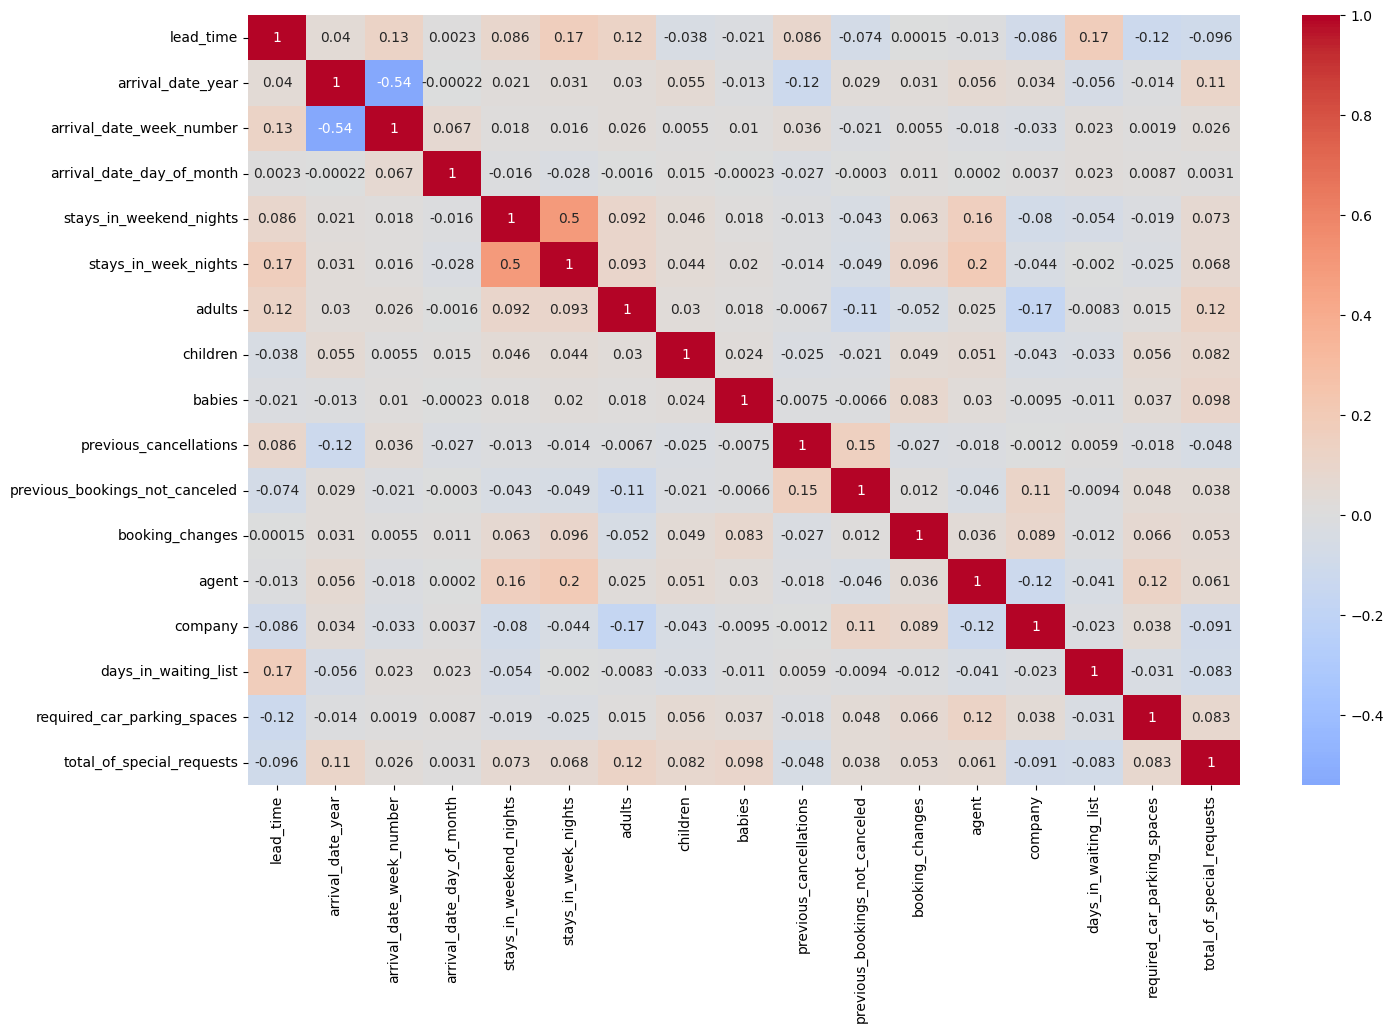

In [56]:
corr_df = df.select_dtypes(include='Int64').corr()
sns.heatmap(corr_df, annot=True, cmap= 'coolwarm', center=0)
plt.show()